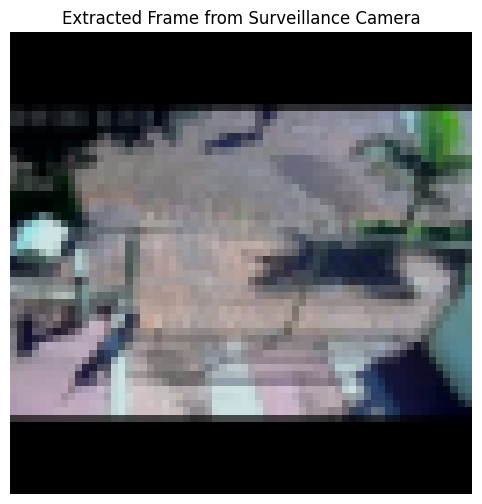

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Define the exact path to ONE of your surveillance image frames
image_path = "Datasets/UCF Crime Dataset/Test/Abuse/Abuse028_x264_0.png" 

# 2. Read the image directly using OpenCV
frame = cv2.imread(image_path)

# 3. Check if the image loaded successfully
if frame is not None:
    # OpenCV reads colors backwards as BGR (Blue, Green, Red). 
    # We need to flip it to standard RGB so the colors look normal.
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 4. Display the frame
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title("Extracted Frame from Surveillance Camera")
    plt.axis('off') # Hides the axis numbers
    plt.show()
else:
    print("❌ Error: Could not read the image. Double-check your file path and name!")

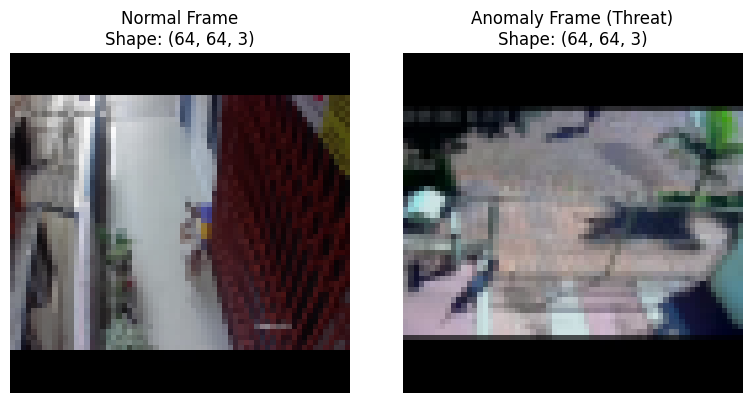

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Define the exact paths to your 64x64 images
normal_path = "Datasets/UCF Crime Dataset/Test/NormalVideos/Normal_Videos_003_x264_20.png"
anomaly_path = "Datasets/UCF Crime Dataset/Test/Abuse/Abuse028_x264_0.png"

# 2. Load the images and fix the BGR to RGB color formatting
img_normal = cv2.cvtColor(cv2.imread(normal_path), cv2.COLOR_BGR2RGB)
img_anomaly = cv2.cvtColor(cv2.imread(anomaly_path), cv2.COLOR_BGR2RGB)

# 3. Display them side-by-side cleanly
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img_normal)
ax[0].set_title(f"Normal Frame\nShape: {img_normal.shape}")
ax[0].axis('off')

ax[1].imshow(img_anomaly)
ax[1].set_title(f"Anomaly Frame (Threat)\nShape: {img_anomaly.shape}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Define the path to your training data folder
train_dir = "Datasets/UCF Crime Dataset/Train"

# Categorize the folders into "Normal" and "Anomaly"
normal_folder = os.path.join(train_dir, "NormalVideos")
anomaly_folders = [f for f in os.listdir(train_dir) if f != "NormalVideos"]

# Count the images
normal_count = len(os.listdir(normal_folder)) if os.path.exists(normal_folder) else 0

anomaly_count = 0
for folder in anomaly_folders:
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        anomaly_count += len(os.listdir(folder_path))

print("=== BORDER SURVEILLANCE DATASET SUMMARY ===")
print(f"Total 'Normal' Frames for training:  {normal_count}")
print(f"Total 'Anomaly' Frames for training: {anomaly_count}")
print(f"Total Combined Images:               {normal_count + anomaly_count}")

=== BORDER SURVEILLANCE DATASET SUMMARY ===
Total 'Normal' Frames for training:  947768
Total 'Anomaly' Frames for training: 318577
Total Combined Images:               1266345


In [6]:
import tensorflow as tf

BATCH_SIZE = 64
IMG_SIZE = (64, 64)
train_dir = "Datasets/UCF Crime Dataset/Train"

print("Setting up Training Data Pipeline...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True, 
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2, 
    subset="training",
    seed=123 
)

print("\nSetting up Validation (Testing) Data Pipeline...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

class_names = train_dataset.class_names
print(f"\nThe AI will learn to detect {len(class_names)} different categories:")
print(class_names)

Setting up Training Data Pipeline...
Found 1266345 files belonging to 14 classes.
Using 1013076 files for training.

Setting up Validation (Testing) Data Pipeline...
Found 1266345 files belonging to 14 classes.
Using 253269 files for validation.

The AI will learn to detect 14 different categories:
['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [7]:
from tensorflow.keras import layers, models

print("Constructing the Neural Network Architecture...")

# 1. Initialize the Sequential Model
model = models.Sequential([
    # First Block: Scanning for basic edges and colors
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)), # Shrinks the data to keep it fast

    # Second Block: Scanning for complex shapes (people, objects)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Block: Deep feature extraction
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Flatten the 2D image data into a 1D array of numbers
    layers.Flatten(),

    # The Decision-Making Layer
    layers.Dense(64, activation='relu'),
    
    # The Output Layer: 14 nodes for your 14 specific categories
    # 'softmax' converts the output into probability percentages (e.g., 90% Explosion, 10% Normal)
    layers.Dense(14, activation='softmax')
])

# 2. Print the blueprint of the network
model.summary()

Constructing the Neural Network Architecture...


C:\Users\PARTHIV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,118 (2.47 MB)

 Trainable params: 647,118 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 1. Compile the Model
print("Compiling the Model...")
model.compile(
    optimizer='adam', # The industry-standard optimizer
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), # Perfect for multi-class categorization
    metrics=['accuracy'] # We want to track the accuracy percentage
)
print("Model Compiled Successfully!")

# 2. Start the Training Process
print("\nStarting Training Phase (Epoch 1/1)...")
print("Grab a coffee, this will take some time to process all 1.2 million frames!")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1 # Keeping it at 1 just to test the pipeline!
)

Compiling the Model...
Model Compiled Successfully!

Starting Training Phase (Epoch 1/1)...
Grab a coffee, this will take some time to process all 1.2 million frames!
15830/15830 ━━━━━━━━━━━━━━━━━━━━ 1382s 87ms/step - accuracy: 0.9686 - loss: 0.1441 - val_accuracy: 0.9844 - val_loss: 0.0586


In [9]:
import numpy as np

# 1. SAVE THE MODEL (Crucial step!)
# This creates a file on your computer containing the trained "brain"
model.save('border_defense_model.keras')
print("✅ AI Model successfully saved to your hard drive!")

# 2. TEST THE AI ON A REAL FRAME
# Let's use the exact Anomaly image we looked at earlier
test_image_path = "Datasets/UCF Crime Dataset/Test/Abuse/Abuse028_x264_0.png"

# Load the image and format it exactly how the AI expects it (64x64)
img = tf.keras.utils.load_img(test_image_path, target_size=(64, 64))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Tricks the AI into thinking this is a "batch" of 1 image

# 3. THE PREDICTION
print("\nAsking the AI to analyze the CCTV frame...")
predictions = model.predict(img_array)

# The model outputs a list of 14 percentages. We want the highest one.
score = predictions[0] 
predicted_category = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

# 4. THE RESULTS
print("========================================")
print(f"🚨 THREAT ASSESSMENT COMPLETE 🚨")
print(f"Predicted Activity : {predicted_category}")
print(f"AI Confidence Level: {confidence:.2f}%")
print("========================================")

✅ AI Model successfully saved to your hard drive!

Asking the AI to analyze the CCTV frame...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
🚨 THREAT ASSESSMENT COMPLETE 🚨
Predicted Activity : Abuse
AI Confidence Level: 62.28%


In [10]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

print("Loading your saved AI model...")
model = tf.keras.models.load_model('border_defense_model.keras')

# 1. The Safety Net: Auto-save the best version
checkpoint = ModelCheckpoint(
    'best_border_defense_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, # Only overwrites if the score improves!
    mode='max',
    verbose=1
)

# 2. The Fast-Track Run (3 Passes)
print("\nStarting Fast-Track Training (3 Epochs)...")
print("Grab a coffee, this will take some time to process all 1.2 million frames!")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3, 
    callbacks=[checkpoint]
)

print("\n✅ Training complete! The smartest version of your model is safely saved.")

Loading your saved AI model...

Starting Fast-Track Training (3 Epochs)...
Grab a coffee, this will take some time to process all 1.2 million frames!
Epoch 1/3
15829/15830 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9874 - loss: 0.0514
Epoch 1: val_accuracy improved from None to 0.99095, saving model to best_border_defense_model.keras

Epoch 1: finished saving model to best_border_defense_model.keras
15830/15830 ━━━━━━━━━━━━━━━━━━━━ 729s 46ms/step - accuracy: 0.9887 - loss: 0.0472 - val_accuracy: 0.9909 - val_loss: 0.0475
Epoch 2/3
15829/15830 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9915 - loss: 0.0364
Epoch 2: val_accuracy improved from 0.99095 to 0.99283, saving model to best_border_defense_model.keras

Epoch 2: finished saving model to best_border_defense_model.keras
15830/15830 ━━━━━━━━━━━━━━━━━━━━ 671s 42ms/step - accuracy: 0.9918 - loss: 0.0355 - val_accuracy: 0.9928 - val_loss: 0.0393
Epoch 3/3
15829/15830 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9928 - loss: 

In [1]:
import cv2
import numpy as np
import tensorflow as tf
from collections import deque
import os
import time
from datetime import datetime
import winsound # Hardware alarm for Windows

print("Loading the trained AI brain...")
model = tf.keras.models.load_model('best_border_defense_model.keras')

class_names = ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']

# --- NEW: Create the Evidence Folder ---
if not os.path.exists('Threat_Logs'):
    os.makedirs('Threat_Logs')
    print("Created 'Threat_Logs' folder for saving evidence.")

# Change this to your threat video (like video4.webm)
video_path = r"C:\Users\PARTHIV\Documents\Border_Surveillance_Project\test_video.mp4" 
cap = cv2.VideoCapture(video_path)

prediction_buffer = deque(maxlen=15)

# --- NEW: Alarm Cooldown Timer ---
last_alert_time = 0
cooldown_seconds = 5 

if not cap.isOpened():
    print(f"🚨 ERROR: Cannot open {video_path}")
else:
    print(f"Opening Surveillance Feed for {video_path}...")

    while cap.isOpened():
        ret, frame = cap.read()
        
        # --- MODIFIED: Exit if video reaches the end ---
        if not ret:
            print("Video end reached.")
            break 
        
        # AI Processing
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized_frame = cv2.resize(rgb_frame, (64, 64))
        img_array = tf.expand_dims(resized_frame, 0) 
        
        predictions = model.predict(img_array, verbose=0)
        score = predictions[0]
        confidence = 100 * np.max(score)
        
        # Smoothing Memory
        prediction_buffer.append(class_names[np.argmax(score)])
        display_class = max(set(prediction_buffer), key=prediction_buffer.count)
        
        text = f"THREAT: {display_class} ({confidence:.1f}%)"
        color = (0, 255, 0) if display_class == 'NormalVideos' else (0, 0, 255)
        
        # --- THE AUTOMATED ALARM & LOGGER ---
        current_time = time.time()
        if display_class != 'NormalVideos' and confidence > 70.0:
            if (current_time - last_alert_time) > cooldown_seconds:
                winsound.Beep(1000, 500)
                timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                file_timestamp = datetime.now().strftime("%H-%M-%S")
                
                evidence_frame = frame.copy()
                cv2.putText(evidence_frame, f"EVIDENCE LOGGED: {timestamp_str}", (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                filename = f"Threat_Logs/{display_class}_Threat_{file_timestamp}.jpg"
                cv2.imwrite(filename, evidence_frame)
                print(f"🚨 ALERT! {display_class} detected. Evidence saved to {filename}")
                
                last_alert_time = current_time

        # Draw the normal HUD
        cv2.putText(frame, text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)
        cv2.imshow('Live Border Surveillance Feed', frame)
        
        if cv2.waitKey(30) & 0xFF == ord('q'): break
        if cv2.getWindowProperty('Live Border Surveillance Feed', cv2.WND_PROP_VISIBLE) < 1: break

    cap.release()
    cv2.destroyAllWindows()
    print("System offline.")

Loading the trained AI brain...
Opening Surveillance Feed for C:\Users\PARTHIV\Documents\Border_Surveillance_Project\test_video.mp4...
System offline.


In [1]:
import cv2
import numpy as np
import tensorflow as tf
from collections import deque
import os
import time
from datetime import datetime
import winsound # Hardware alarm for Windows

print("Loading the trained AI brain...")
model = tf.keras.models.load_model('best_border_defense_model.keras')

class_names = ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']

# --- NEW: Create the Evidence Folder ---
if not os.path.exists('Threat_Logs'):
    os.makedirs('Threat_Logs')
    print("Created 'Threat_Logs' folder for saving evidence.")

# Change this to your threat video (like video4.webm)
video_path = r"C:\Users\PARTHIV\Documents\Border_Surveillance_Project\video2.mp4" 
cap = cv2.VideoCapture(video_path)

prediction_buffer = deque(maxlen=15)

# --- NEW: Alarm Cooldown Timer ---
last_alert_time = 0
cooldown_seconds = 5 

if not cap.isOpened():
    print(f"🚨 ERROR: Cannot open {video_path}")
else:
    print(f"Opening Surveillance Feed for {video_path}...")

    while cap.isOpened():
        ret, frame = cap.read()
        
        # --- MODIFIED: Exit if video reaches the end ---
        if not ret:
            print("Video end reached.")
            break 
        
        # AI Processing
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized_frame = cv2.resize(rgb_frame, (64, 64))
        img_array = tf.expand_dims(resized_frame, 0) 
        
        predictions = model.predict(img_array, verbose=0)
        score = predictions[0]
        confidence = 100 * np.max(score)
        
        # Smoothing Memory
        prediction_buffer.append(class_names[np.argmax(score)])
        display_class = max(set(prediction_buffer), key=prediction_buffer.count)
        
        text = f"THREAT: {display_class} ({confidence:.1f}%)"
        color = (0, 255, 0) if display_class == 'NormalVideos' else (0, 0, 255)
        
        # --- THE AUTOMATED ALARM & LOGGER ---
        current_time = time.time()
        if display_class != 'NormalVideos' and confidence > 70.0:
            if (current_time - last_alert_time) > cooldown_seconds:
                winsound.Beep(1000, 500)
                timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                file_timestamp = datetime.now().strftime("%H-%M-%S")
                
                evidence_frame = frame.copy()
                cv2.putText(evidence_frame, f"EVIDENCE LOGGED: {timestamp_str}", (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                filename = f"Threat_Logs/{display_class}_Threat_{file_timestamp}.jpg"
                cv2.imwrite(filename, evidence_frame)
                print(f"🚨 ALERT! {display_class} detected. Evidence saved to {filename}")
                
                last_alert_time = current_time

        # Draw the normal HUD
        cv2.putText(frame, text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)
        cv2.imshow('Live Border Surveillance Feed', frame)
        
        if cv2.waitKey(30) & 0xFF == ord('q'): break
        if cv2.getWindowProperty('Live Border Surveillance Feed', cv2.WND_PROP_VISIBLE) < 1: break

    cap.release()
    cv2.destroyAllWindows()
    print("System offline.")

Loading the trained AI brain...
Opening Surveillance Feed for C:\Users\PARTHIV\Documents\Border_Surveillance_Project\video2.mp4...
🚨 ALERT! Shooting detected. Evidence saved to Threat_Logs/Shooting_Threat_12-20-53.jpg
Video end reached.
System offline.
